# Machine Learning-Based Cross-Sectional Stock Selection for the S&P 500

**MSE 623 Final Project**

**Team:** Chenyu Liu · Yi Lu · Yukang Luo

---

## Pipeline Overview

| Step | Description |
|------|-------------|
| 1 | Data Loading |
| 2 | Data Preprocessing |
| 3 | Feature Construction (8 technical indicators) |
| 4 | Target Construction (Sep return + binary label) |
| 5 | Expanding-Window Cross-Validation |
| 6 | Final Out-of-Sample Testing (2017) |
| 7 | Portfolio Construction & Evaluation |
| 8 | Robustness Analysis |

**Formation month:** August (post-Q2 earnings)  
**Prediction target:** September cross-sectional stock returns  
**Models:** Logistic Regression · Random Forest · XGBoost  
**Portfolio:** Equal-weighted top-20% vs equal-weighted S&P 500 benchmark  


## Step 1: Imports & Configuration


In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 4.2/101.7 MB 36.1 MB/s eta 0:00:03
   ---- ----------------------------------- 10.5/101.7 MB 27.3 MB/s eta 0:00:04
   ------ --------------------------------- 16.3/101.7 MB 26.9 MB/s eta 0:00:04
   -------- ------------------------------- 21.0/101.7 MB 26.0 MB/s eta 0:00:04
   ---------- ----------------------------- 26.0/101.7 MB 25.7 MB/s eta 0:00:03
   ------------ --------------------------- 31.5/101.7 MB 25.9 MB/s eta 0:00:03
   -------------- ------------------------- 37.5/101.7 MB 26.2 MB/s eta 0:00:03
   ----------------- ---------------------- 44.0/101.7 MB 26.9 MB/s eta 0:00:03
   ------------------- -------------------- 50.6/101.7 MB 27.3 MB/s eta 0:00:02
   ---------------------- ----------------- 56.9/101.7 MB 27.4 MB/s eta 0:00:02
   ------------------------ --------------- 62.1/101.7 MB 27.3 MB/s eta 0:00:02
   -------------------------- ------------- 68.2/1

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              mean_squared_error, mean_absolute_error)
from sklearn.preprocessing import StandardScaler

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('XGBoost: available')
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost: not installed — XGBoost section will be skipped')

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_style('whitegrid')
np.random.seed(42)

print('All libraries loaded successfully.')

XGBoost: available
All libraries loaded successfully.


## Step 2: Data Loading

We load all 505 individual stock CSV files from the local data directory.  
Each file contains daily OHLCV data for one S&P 500 constituent (Feb 2013 – Feb 2018).


In [4]:
DATA_PATH = r'E:\MSE 623\project\archive\individual_stocks_5yr'

all_data = []
for file in sorted(os.listdir(DATA_PATH)):
    if file.endswith('.csv'):
        try:
            df = pd.read_csv(os.path.join(DATA_PATH, file))
            all_data.append(df)
        except Exception as e:
            print(f'  Warning: Could not load {file}: {e}')

data = pd.concat(all_data, ignore_index=True)
data.columns = [c.lower().strip() for c in data.columns]
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['name', 'date']).reset_index(drop=True)

print('=== Dataset Overview ===')
print(f'Total records  : {len(data):,}')
print(f'Unique tickers : {data["name"].nunique()}')
print(f'Date range     : {data["date"].min().date()} to {data["date"].max().date()}')
print(f'Columns        : {list(data.columns)}')
data.head()

=== Dataset Overview ===
Total records  : 619,040
Unique tickers : 505
Date range     : 2013-02-08 to 2018-02-07
Columns        : ['date', 'open', 'high', 'low', 'close', 'volume', 'name']


,date,open,high,low,close,volume,name
0,2013-02-08,45.07,45.35,45.00,45.08,1824755,A
1,2013-02-11,45.17,45.18,44.45,44.60,2915405,A
2,2013-02-12,44.81,44.95,44.50,44.62,2373731,A
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A


In [5]:
# Verify August and September data availability for our target years
print('Data availability for target months (Aug & Sep, 2013-2017):\n')
for year in range(2013, 2018):
    aug = data[(data['date'].dt.year == year) & (data['date'].dt.month == 8)]
    sep = data[(data['date'].dt.year == year) & (data['date'].dt.month == 9)]
    print(f'  {year}  Aug: {len(aug):5,} records ({aug["name"].nunique()} stocks) | '
          f'Sep: {len(sep):5,} records ({sep["name"].nunique()} stocks)')

Data availability for target months (Aug & Sep, 2013-2017):

  2013  Aug: 10,604 records (482 stocks) | Sep: 9,631 records (482 stocks)
  2014  Aug: 10,227 records (487 stocks) | Sep: 10,232 records (488 stocks)
  2015  Aug: 10,332 records (492 stocks) | Sep: 10,332 records (492 stocks)
  2016  Aug: 11,454 records (498 stocks) | Sep: 10,458 records (498 stocks)
  2017  Aug: 11,569 records (503 stocks) | Sep: 10,080 records (504 stocks)


## Step 3: Data Preprocessing

- Remove rows with missing OHLCV values
- Remove rows with zero or negative prices/volume


In [6]:
print('Missing values before cleaning:')
print(data[['open','high','low','close','volume']].isnull().sum())

data.dropna(subset=['open','high','low','close','volume'], inplace=True)
data = data[(data['close'] > 0) & (data['volume'] > 0) &
            (data['high'] > 0)  & (data['low'] > 0)].copy()
data.reset_index(drop=True, inplace=True)

print(f'\nRecords after cleaning: {len(data):,}')
print('Missing values after cleaning:')
print(data[['open','high','low','close','volume']].isnull().sum())

Missing values before cleaning:
open      11
high       8
low        8
close      0
volume     0
dtype: int64

Records after cleaning: 619,029
Missing values after cleaning:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


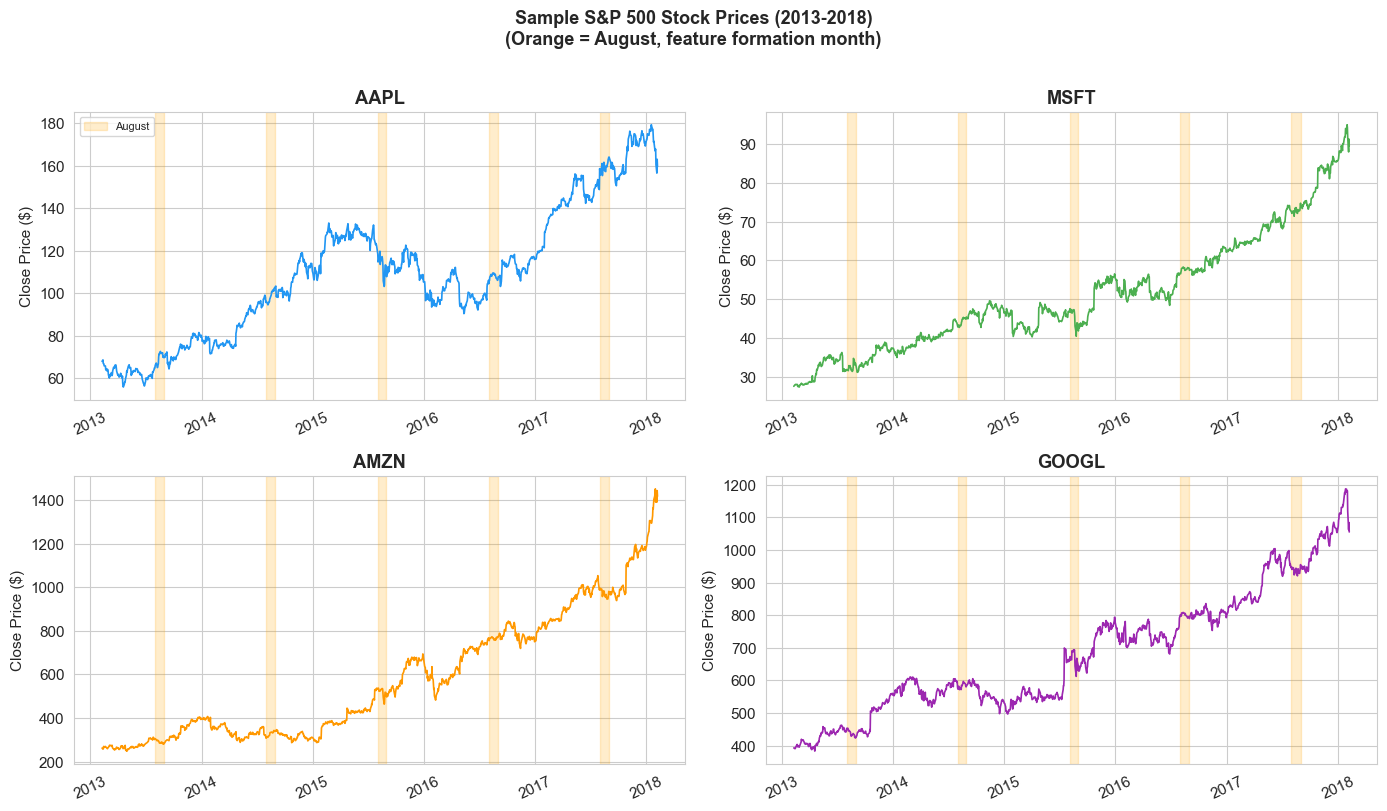

Saved: price_history.png


In [7]:
# Exploratory visualization: sample stock price histories
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sample_tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for ax, ticker, color in zip(axes.flat, sample_tickers, colors):
    stock = data[data['name'] == ticker]
    ax.plot(stock['date'], stock['close'], color=color, linewidth=1.2)
    for year in range(2013, 2018):
        aug = stock[(stock['date'].dt.year == year) & (stock['date'].dt.month == 8)]
        if len(aug) > 0:
            ax.axvspan(aug['date'].min(), aug['date'].max(), alpha=0.2, color='orange',
                       label='August' if year == 2013 else '')
    ax.set_title(ticker, fontweight='bold')
    ax.set_ylabel('Close Price ($)')
    ax.tick_params(axis='x', rotation=25)
    if ticker == 'AAPL':
        ax.legend(fontsize=8)

plt.suptitle('Sample S&P 500 Stock Prices (2013-2018)\n'
             '(Orange = August, feature formation month)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('price_history.png', bbox_inches='tight')
plt.show()
print('Saved: price_history.png')

## Step 4: Feature Engineering

We compute **8 technical indicators** at the **last trading day of August** each year.  
One month is approximated as **21 trading days**.

| Category   | Feature               | Definition |
|------------|-----------------------|------------|
| Momentum   | `Momentum_1M`         | (Close_t / Close_{t-21}) − 1 |
| Momentum   | `Momentum_3M`         | (Close_t / Close_{t-63}) − 1 |
| Trend      | `Price_to_MA20`       | Close_t / MA20_t |
| Trend      | `MA_20_slope`         | OLS slope of last 20 closing prices on time index |
| Volatility | `Volatility_20d`      | Std of daily returns over last 20 days |
| Volatility | `High_Low_Range`      | High_t / Low_t (last Aug trading day) |
| Volume     | `Volume_Ratio`        | Volume_t / Volume_MA20_t |
| Volume     | `1M_Accum_Vol_Change` | (CumVol_curr21 − CumVol_prev21) / CumVol_prev21 |

**Target:** September return = (Close_last_Sep / Close_last_Aug) − 1


In [8]:
FEATURE_COLS = [
    'Momentum_1M', 'Momentum_3M', 'Price_to_MA20', 'MA_20_slope',
    'Volatility_20d', 'High_Low_Range', 'Volume_Ratio', '1M_Accum_Vol_Change'
]


def compute_ols_slope(prices):
    """OLS slope of price regressed on time index (0, 1, ..., n-1)."""
    x = np.arange(len(prices), dtype=float)
    slope, _, _, _, _ = stats.linregress(x, prices)
    return slope


def compute_features_for_stock_year(stock_df, year, min_history=65):
    """
    Compute 8 technical features at August month-end for a given year.
    Also returns the September return as the regression target.

    Returns a feature dict or None if data is insufficient.
    """
    aug_days = stock_df[
        (stock_df['date'].dt.year == year) & (stock_df['date'].dt.month == 8)]
    sep_days = stock_df[
        (stock_df['date'].dt.year == year) & (stock_df['date'].dt.month == 9)]

    if len(aug_days) < 10 or len(sep_days) < 10:
        return None

    last_aug_date = aug_days['date'].max()
    last_aug_row  = aug_days.loc[aug_days['date'] == last_aug_date].iloc[0]
    last_sep_close = sep_days.loc[
        sep_days['date'] == sep_days['date'].max(), 'close'].values[0]

    # Full history up to last August trading day
    hist = stock_df[stock_df['date'] <= last_aug_date].copy()
    if len(hist) < min_history:
        return None

    closes  = hist['close'].values.astype(float)
    volumes = hist['volume'].values.astype(float)

    if np.any(closes <= 0) or np.any(volumes <= 0):
        return None
    if len(closes) < 64 or len(volumes) < 42:
        return None

    # 1. Momentum_1M
    momentum_1m = (closes[-1] / closes[-22]) - 1

    # 2. Momentum_3M
    momentum_3m = (closes[-1] / closes[-64]) - 1

    # 3. Price_to_MA20
    ma20 = np.mean(closes[-20:])
    price_to_ma20 = closes[-1] / ma20

    # 4. MA_20_slope
    ma20_slope = compute_ols_slope(closes[-20:])

    # 5. Volatility_20d
    daily_rets = closes[1:] / closes[:-1] - 1
    volatility_20d = np.std(daily_rets[-20:])

    # 6. High_Low_Range
    high_low_range = float(last_aug_row['high']) / float(last_aug_row['low'])

    # 7. Volume_Ratio
    volume_ma20 = np.mean(volumes[-20:])
    if volume_ma20 == 0:
        return None
    volume_ratio = float(last_aug_row['volume']) / volume_ma20

    # 8. 1M_Accum_Vol_Change
    cum_vol_curr = np.sum(volumes[-21:])
    cum_vol_prev = np.sum(volumes[-42:-21])
    if cum_vol_prev == 0:
        return None
    accum_vol_change = (cum_vol_curr - cum_vol_prev) / cum_vol_prev

    # Target: September return
    sep_return = (last_sep_close / closes[-1]) - 1

    return {
        'ticker':               stock_df['name'].iloc[0],
        'year':                 year,
        'Momentum_1M':          momentum_1m,
        'Momentum_3M':          momentum_3m,
        'Price_to_MA20':        price_to_ma20,
        'MA_20_slope':          ma20_slope,
        'Volatility_20d':       volatility_20d,
        'High_Low_Range':       high_low_range,
        'Volume_Ratio':         volume_ratio,
        '1M_Accum_Vol_Change':  accum_vol_change,
        'Sep_Return':           sep_return,
    }


print(f'Feature engineering functions ready.')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Feature engineering functions ready.
Features (8): ['Momentum_1M', 'Momentum_3M', 'Price_to_MA20', 'MA_20_slope', 'Volatility_20d', 'High_Low_Range', 'Volume_Ratio', '1M_Accum_Vol_Change']


## Step 5: Build Feature-Target Dataset

We iterate over all stocks and years (2013–2017), computing features at each August month-end.


In [9]:
YEARS = [2013, 2014, 2015, 2016, 2017]
tickers = data['name'].unique()

print(f'Building dataset: {len(tickers)} stocks x {len(YEARS)} years')
print('(This may take 1-3 minutes...)\n')

records = []
for i, ticker in enumerate(tickers):
    stock_df = (data[data['name'] == ticker]
                .sort_values('date')
                .reset_index(drop=True))
    for year in YEARS:
        rec = compute_features_for_stock_year(stock_df, year)
        if rec is not None:
            records.append(rec)
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(tickers)} stocks processed... ({len(records)} valid records)')

features_df = pd.DataFrame(records).dropna().reset_index(drop=True)

print(f'\n=== Feature Dataset ===')
print(f'Total valid observations: {len(features_df):,}')
print(f'\nObservations per year:')
print(features_df['year'].value_counts().sort_index().to_frame('count'))
features_df.head()

Building dataset: 505 stocks x 5 years
(This may take 1-3 minutes...)

  100/505 stocks processed... (482 valid records)
  200/505 stocks processed... (959 valid records)
  300/505 stocks processed... (1443 valid records)
  400/505 stocks processed... (1935 valid records)
  500/505 stocks processed... (2424 valid records)

=== Feature Dataset ===
Total valid observations: 2,449

Observations per year:
      count
year       
2013    477
2014    485
2015    489
2016    497
2017    501


,ticker,year,Momentum_1M,Momentum_3M,Price_to_MA20,MA_20_slope,Volatility_20d,High_Low_Range,Volume_Ratio,1M_Accum_Vol_Change,Sep_Return
0,A,2013,0.013032,0.024830,0.997903,0.061925,0.008906,1.013155,0.603951,-0.019870,0.098842
1,A,2014,0.019076,0.004746,1.008807,0.161910,0.011592,1.007358,1.063870,0.018401,-0.003149
2,A,2015,-0.113309,-0.116760,0.953594,-0.298316,0.018473,1.016759,0.942438,0.131969,-0.054530
3,A,2016,-0.004239,0.023529,0.988335,-0.018639,0.012254,1.008172,0.828287,0.155879,0.002341
4,A,2017,0.075083,0.064299,1.051853,0.266940,0.014242,1.014554,0.965162,0.231414,-0.008035


## Step 5 (cont.): Target Construction

**Regression target:** `Sep_Return` — actual September return for each stock.  
**Binary target:** `Binary_Target` — 1 if return ≥ cross-sectional median for that year, else 0.  
This ensures balanced classes and captures relative (cross-sectional) performance.


In [10]:
# Binary cross-sectional target
features_df['Binary_Target'] = features_df.groupby('year')['Sep_Return'].transform(
    lambda x: (x >= x.median()).astype(int)
)

print('=== Binary Target Distribution (0=bottom half, 1=top half) ===')
print(features_df.groupby('year')['Binary_Target'].value_counts().unstack())

print('\n=== September Return Statistics by Year ===')
print(features_df.groupby('year')['Sep_Return'].describe().round(4))

=== Binary Target Distribution (0=bottom half, 1=top half) ===
Binary_Target    0    1
year                   
2013           238  239
2014           242  243
2015           244  245
2016           248  249
2017           250  251

=== September Return Statistics by Year ===
      count    mean     std     min     25%     50%     75%     max
year                                                               
2013  477.0  0.0426  0.0521 -0.1155  0.0099  0.0411  0.0719  0.2912
2014  485.0 -0.0254  0.0486 -0.1823 -0.0544 -0.0253  0.0046  0.2144
2015  489.0 -0.0296  0.0613 -0.2922 -0.0656 -0.0244  0.0114  0.2193
2016  497.0 -0.0011  0.0487 -0.1977 -0.0267 -0.0026  0.0219  0.2851
2017  501.0  0.0270  0.0642 -0.2561 -0.0175  0.0251  0.0644  0.2502


## Step 5 (cont.): Exploratory Data Analysis


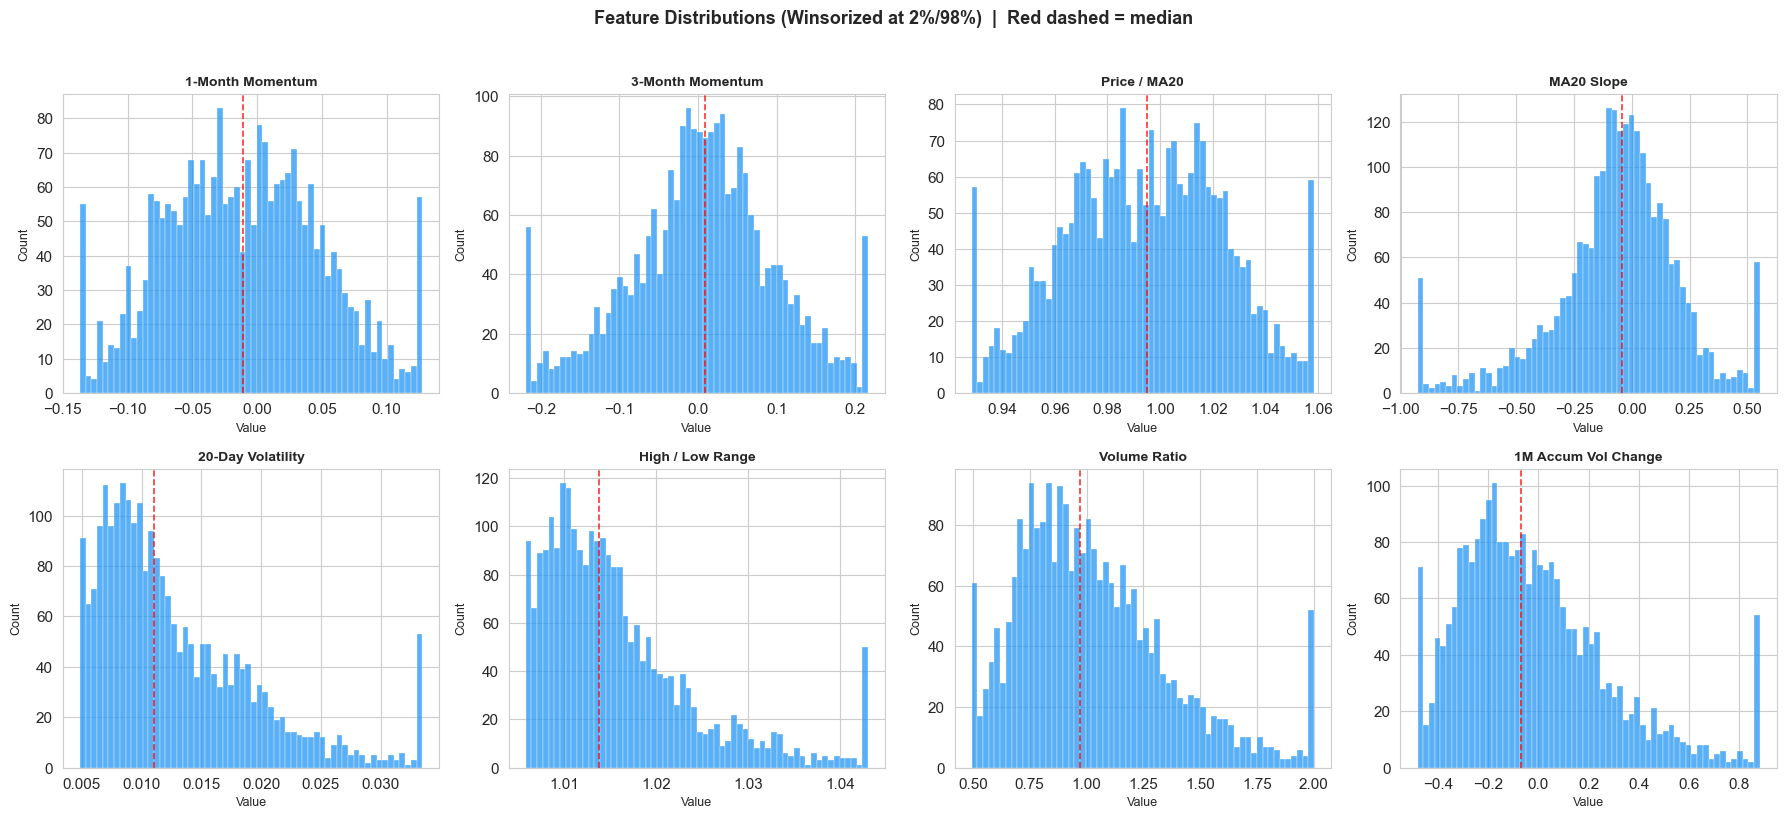

Saved: feature_distributions.png


In [11]:
# Feature distribution histograms
feature_labels = {
    'Momentum_1M':         '1-Month Momentum',
    'Momentum_3M':         '3-Month Momentum',
    'Price_to_MA20':       'Price / MA20',
    'MA_20_slope':         'MA20 Slope',
    'Volatility_20d':      '20-Day Volatility',
    'High_Low_Range':      'High / Low Range',
    'Volume_Ratio':        'Volume Ratio',
    '1M_Accum_Vol_Change': '1M Accum Vol Change',
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, (col, label) in zip(axes.flat, feature_labels.items()):
    vals = features_df[col].clip(
        features_df[col].quantile(0.02),
        features_df[col].quantile(0.98)
    )
    ax.hist(vals, bins=60, color='#2196F3', alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(vals.median(), color='red', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)

plt.suptitle('Feature Distributions (Winsorized at 2%/98%)  |  Red dashed = median',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

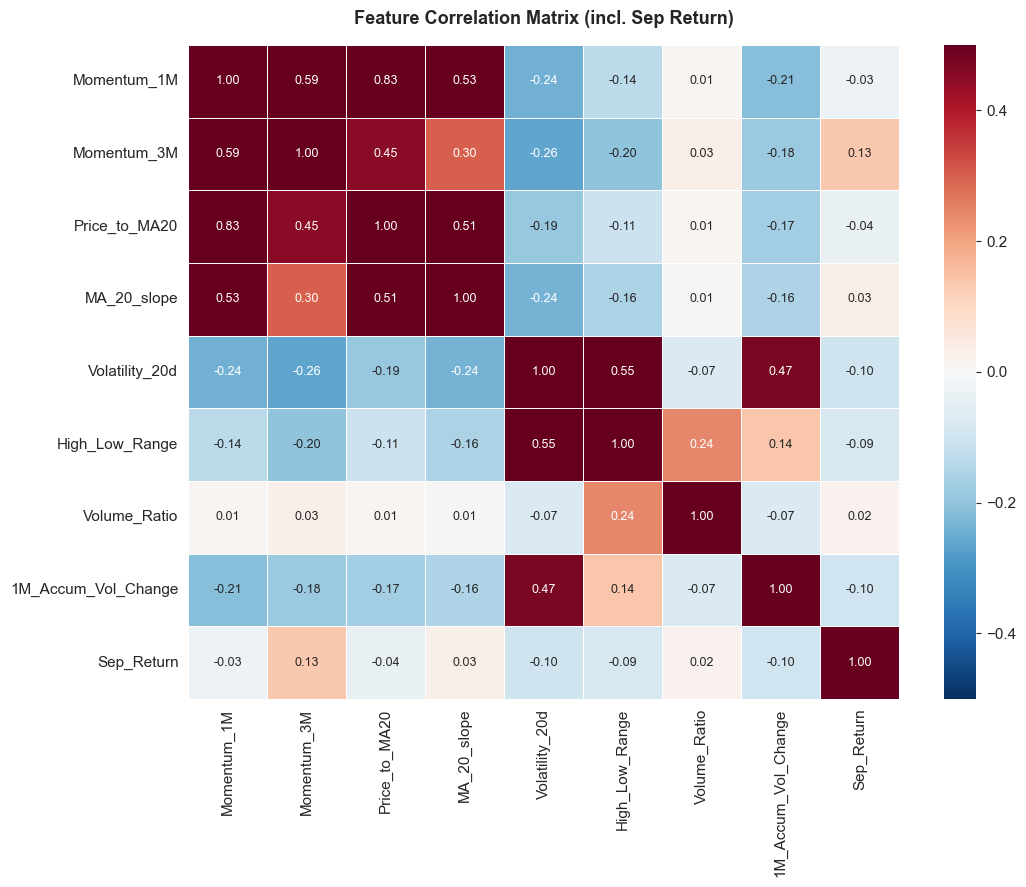

Saved: feature_correlation.png


In [12]:
# Feature correlation heatmap (including Sep Return)
fig, ax = plt.subplots(figsize=(11, 9))
corr = features_df[FEATURE_COLS + ['Sep_Return']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, vmin=-0.5, vmax=0.5, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix (incl. Sep Return)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('feature_correlation.png', bbox_inches='tight')
plt.show()
print('Saved: feature_correlation.png')

## Step 6: Time-Series Cross-Validation (Expanding Window)

To prevent **look-ahead bias**, we use expanding-window cross-validation —  
training only on data that would have been available at each decision point.

| Training Data | Validation Data |
|---------------|-----------------|
| 2013          | 2014            |
| 2013–2014     | 2015            |
| 2013–2015     | 2016            |

After selecting optimal hyperparameters via CV, the final model is trained on  
**2013–2016** and evaluated on the **2017 holdout set**.


In [13]:
CV_FOLDS = [
    ([2013],             2014),
    ([2013, 2014],       2015),
    ([2013, 2014, 2015], 2016),
]
FINAL_TRAIN_YEARS = [2013, 2014, 2015, 2016]
TEST_YEAR = 2017


def get_split(df, train_years, val_year):
    """Return train/val arrays and the full val DataFrame."""
    tr = df[df['year'].isin(train_years)]
    va = df[df['year'] == val_year]
    return (
        tr[FEATURE_COLS].values,
        tr['Sep_Return'].values,
        tr['Binary_Target'].values,
        va[FEATURE_COLS].values,
        va['Sep_Return'].values,
        va['Binary_Target'].values,
        va.reset_index(drop=True),
    )


print('Expanding-window CV structure:')
print('-' * 60)
for train_yrs, val_yr in CV_FOLDS:
    n_tr = len(features_df[features_df['year'].isin(train_yrs)])
    n_va = len(features_df[features_df['year'] == val_yr])
    print(f'  Train: {train_yrs}  ({n_tr} obs)  ->  Val: {val_yr}  ({n_va} obs)')
n_te = len(features_df[features_df['year'] == TEST_YEAR])
print(f'  Final test: {TEST_YEAR}  ({n_te} obs)')
print('-' * 60)

Expanding-window CV structure:
------------------------------------------------------------
  Train: [2013]  (477 obs)  ->  Val: 2014  (485 obs)
  Train: [2013, 2014]  (962 obs)  ->  Val: 2015  (489 obs)
  Train: [2013, 2014, 2015]  (1451 obs)  ->  Val: 2016  (497 obs)
  Final test: 2017  (501 obs)
------------------------------------------------------------


### 6.1 Logistic Regression — Cross-Validation


In [14]:
print('=' * 65)
print('LOGISTIC REGRESSION  —  Hyperparameter Search (C by avg AUC)')
print('=' * 65)

LR_C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0]
lr_c_aucs = {C: [] for C in LR_C_GRID}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
        features_df, train_yrs, val_yr)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_va_sc = scaler.transform(X_va)
    for C in LR_C_GRID:
        lr = LogisticRegression(C=C, max_iter=2000, random_state=42, solver='lbfgs')
        lr.fit(X_tr_sc, y_tr_c)
        prob = lr.predict_proba(X_va_sc)[:, 1]
        lr_c_aucs[C].append(roc_auc_score(y_va_c, prob))

lr_avg_aucs = {C: np.mean(v) for C, v in lr_c_aucs.items()}
BEST_C_LR = max(lr_avg_aucs, key=lr_avg_aucs.get)

print(f'  {"C":>8} | {"Fold1":>8} | {"Fold2":>8} | {"Fold3":>8} | {"Avg AUC":>8}')
print('  ' + '-' * 52)
for C in LR_C_GRID:
    aucs = lr_c_aucs[C]
    marker = '  <- BEST' if C == BEST_C_LR else ''
    print(f'  {C:>8.3f} | {aucs[0]:>8.4f} | {aucs[1]:>8.4f} | {aucs[2]:>8.4f} | '
          f'{np.mean(aucs):>8.4f}{marker}')
print(f'\nSelected C = {BEST_C_LR}')

LOGISTIC REGRESSION  —  Hyperparameter Search (C by avg AUC)
         C |    Fold1 |    Fold2 |    Fold3 |  Avg AUC
  ----------------------------------------------------
     0.001 |   0.5145 |   0.5203 |   0.5287 |   0.5212  <- BEST
     0.010 |   0.5198 |   0.4942 |   0.5337 |   0.5159
     0.100 |   0.5213 |   0.4949 |   0.5414 |   0.5192
     1.000 |   0.5226 |   0.4953 |   0.5443 |   0.5207
    10.000 |   0.5226 |   0.4953 |   0.5444 |   0.5208

Selected C = 0.001


In [15]:
print(f'\nLogistic Regression CV Results  (C={BEST_C_LR})')
print('-' * 50)

lr_cv_results = []
lr_val_preds  = {}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
        features_df, train_yrs, val_yr)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_va_sc = scaler.transform(X_va)

    lr = LogisticRegression(C=BEST_C_LR, max_iter=2000, random_state=42, solver='lbfgs')
    lr.fit(X_tr_sc, y_tr_c)
    prob = lr.predict_proba(X_va_sc)[:, 1]
    pred = (prob >= 0.5).astype(int)

    acc = accuracy_score(y_va_c, pred)
    auc = roc_auc_score(y_va_c, prob)
    lr_cv_results.append({'val_year': val_yr, 'accuracy': acc, 'auc': auc})
    lr_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                            'score': prob, 'actual': y_va_r}
    print(f'  Val {val_yr}:  Accuracy = {acc:.4f}  |  AUC = {auc:.4f}')

lr_cv_df = pd.DataFrame(lr_cv_results)
print(f'\n  Mean Accuracy : {lr_cv_df.accuracy.mean():.4f} +/- {lr_cv_df.accuracy.std():.4f}')
print(f'  Mean AUC      : {lr_cv_df.auc.mean():.4f} +/- {lr_cv_df.auc.std():.4f}')


Logistic Regression CV Results  (C=0.001)
--------------------------------------------------
  Val 2014:  Accuracy = 0.5072  |  AUC = 0.5145
  Val 2015:  Accuracy = 0.5112  |  AUC = 0.5203
  Val 2016:  Accuracy = 0.4950  |  AUC = 0.5287

  Mean Accuracy : 0.5045 +/- 0.0085
  Mean AUC      : 0.5212 +/- 0.0072


### 6.2 Random Forest — Cross-Validation


In [16]:
print('=' * 65)
print('RANDOM FOREST  —  Hyperparameter Search (avg MAE)')
print('=' * 65)

RF_PARAM_GRID = list(product([3, 5, 7], [5, 10]))  # max_depth, min_samples_leaf
rf_param_maes = {p: [] for p in RF_PARAM_GRID}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
        features_df, train_yrs, val_yr)
    for max_d, min_leaf in RF_PARAM_GRID:
        rf = RandomForestRegressor(n_estimators=100, max_depth=max_d,
                                   min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr_r)
        pred = rf.predict(X_va)
        rf_param_maes[(max_d, min_leaf)].append(mean_absolute_error(y_va_r, pred))

rf_avg_maes = {p: np.mean(v) for p, v in rf_param_maes.items()}
BEST_PARAMS_RF = min(rf_avg_maes, key=rf_avg_maes.get)

print(f'  {"max_depth":>10} | {"min_leaf":>8} | {"Fold1":>10} | {"Fold2":>10} | '
      f'{"Fold3":>10} | {"Avg MAE":>10}')
print('  ' + '-' * 68)
for (max_d, min_leaf) in RF_PARAM_GRID:
    maes = rf_param_maes[(max_d, min_leaf)]
    marker = '  <- BEST' if (max_d, min_leaf) == BEST_PARAMS_RF else ''
    print(f'  {max_d:>10} | {min_leaf:>8} | {maes[0]:>10.6f} | {maes[1]:>10.6f} | '
          f'{maes[2]:>10.6f} | {np.mean(maes):>10.6f}{marker}')
print(f'\nSelected: max_depth={BEST_PARAMS_RF[0]}, min_samples_leaf={BEST_PARAMS_RF[1]}')

RANDOM FOREST  —  Hyperparameter Search (avg MAE)
   max_depth | min_leaf |      Fold1 |      Fold2 |      Fold3 |    Avg MAE
  --------------------------------------------------------------------
           3 |        5 |   0.073116 |   0.081474 |   0.038684 |   0.064424  <- BEST
           3 |       10 |   0.073477 |   0.081930 |   0.038721 |   0.064709
           5 |        5 |   0.073415 |   0.082659 |   0.039761 |   0.065278
           5 |       10 |   0.072914 |   0.082490 |   0.039710 |   0.065038
           7 |        5 |   0.073516 |   0.082602 |   0.040724 |   0.065614
           7 |       10 |   0.072994 |   0.082243 |   0.040662 |   0.065300

Selected: max_depth=3, min_samples_leaf=5


In [17]:
print(f'\nRandom Forest CV Results  (max_depth={BEST_PARAMS_RF[0]}, '
      f'min_leaf={BEST_PARAMS_RF[1]})')
print('-' * 50)

rf_cv_results = []
rf_val_preds  = {}

for train_yrs, val_yr in CV_FOLDS:
    X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
        features_df, train_yrs, val_yr)
    max_d, min_leaf = BEST_PARAMS_RF
    rf = RandomForestRegressor(n_estimators=100, max_depth=max_d,
                               min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr_r)
    pred = rf.predict(X_va)

    rmse = np.sqrt(mean_squared_error(y_va_r, pred))
    mae  = mean_absolute_error(y_va_r, pred)
    rf_cv_results.append({'val_year': val_yr, 'rmse': rmse, 'mae': mae})
    rf_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                            'score': pred, 'actual': y_va_r}
    print(f'  Val {val_yr}:  RMSE = {rmse:.6f}  |  MAE = {mae:.6f}')

rf_cv_df = pd.DataFrame(rf_cv_results)
print(f'\n  Mean RMSE : {rf_cv_df.rmse.mean():.6f} +/- {rf_cv_df.rmse.std():.6f}')
print(f'  Mean MAE  : {rf_cv_df.mae.mean():.6f} +/- {rf_cv_df.mae.std():.6f}')


Random Forest CV Results  (max_depth=3, min_leaf=5)
--------------------------------------------------
  Val 2014:  RMSE = 0.085320  |  MAE = 0.073116
  Val 2015:  RMSE = 0.103439  |  MAE = 0.081474
  Val 2016:  RMSE = 0.053451  |  MAE = 0.038684

  Mean RMSE : 0.080737 +/- 0.025307
  Mean MAE  : 0.064424 +/- 0.022680


### 6.3 XGBoost — Cross-Validation


In [18]:
if XGB_AVAILABLE:
    print('=' * 65)
    print('XGBOOST  —  Hyperparameter Search + CV')
    print('=' * 65)

    XGB_PARAM_GRID = list(product([3, 5], [0.05, 0.1]))  # max_depth, learning_rate
    xgb_param_maes = {p: [] for p in XGB_PARAM_GRID}

    for train_yrs, val_yr in CV_FOLDS:
        X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, _ = get_split(
            features_df, train_yrs, val_yr)
        for max_d, lr_rate in XGB_PARAM_GRID:
            model = xgb.XGBRegressor(
                n_estimators=100, max_depth=max_d, learning_rate=lr_rate,
                subsample=0.8, random_state=42, verbosity=0)
            model.fit(X_tr, y_tr_r)
            pred = model.predict(X_va)
            xgb_param_maes[(max_d, lr_rate)].append(mean_absolute_error(y_va_r, pred))

    xgb_avg_maes = {p: np.mean(v) for p, v in xgb_param_maes.items()}
    BEST_PARAMS_XGB = min(xgb_avg_maes, key=xgb_avg_maes.get)

    print(f'  {"max_depth":>10} | {"lr":>6} | {"Fold1":>10} | {"Fold2":>10} | '
          f'{"Fold3":>10} | {"Avg MAE":>10}')
    print('  ' + '-' * 62)
    for (max_d, lr_rate) in XGB_PARAM_GRID:
        maes = xgb_param_maes[(max_d, lr_rate)]
        marker = '  <- BEST' if (max_d, lr_rate) == BEST_PARAMS_XGB else ''
        print(f'  {max_d:>10} | {lr_rate:>6.2f} | {maes[0]:>10.6f} | {maes[1]:>10.6f} | '
              f'{maes[2]:>10.6f} | {np.mean(maes):>10.6f}{marker}')
    print(f'\nSelected: max_depth={BEST_PARAMS_XGB[0]}, learning_rate={BEST_PARAMS_XGB[1]}')

    # CV with best params
    print(f'\nXGBoost CV Results  (max_depth={BEST_PARAMS_XGB[0]}, lr={BEST_PARAMS_XGB[1]})')
    print('-' * 50)
    xgb_cv_results = []
    xgb_val_preds  = {}

    for train_yrs, val_yr in CV_FOLDS:
        X_tr, y_tr_r, y_tr_c, X_va, y_va_r, y_va_c, va_df = get_split(
            features_df, train_yrs, val_yr)
        max_d, lr_rate = BEST_PARAMS_XGB
        model = xgb.XGBRegressor(
            n_estimators=100, max_depth=max_d, learning_rate=lr_rate,
            subsample=0.8, random_state=42, verbosity=0)
        model.fit(X_tr, y_tr_r)
        pred = model.predict(X_va)

        rmse = np.sqrt(mean_squared_error(y_va_r, pred))
        mae  = mean_absolute_error(y_va_r, pred)
        xgb_cv_results.append({'val_year': val_yr, 'rmse': rmse, 'mae': mae})
        xgb_val_preds[val_yr] = {'tickers': va_df['ticker'].values,
                                  'score': pred, 'actual': y_va_r}
        print(f'  Val {val_yr}:  RMSE = {rmse:.6f}  |  MAE = {mae:.6f}')

    xgb_cv_df = pd.DataFrame(xgb_cv_results)
    print(f'\n  Mean RMSE : {xgb_cv_df.rmse.mean():.6f} +/- {xgb_cv_df.rmse.std():.6f}')
    print(f'  Mean MAE  : {xgb_cv_df.mae.mean():.6f} +/- {xgb_cv_df.mae.std():.6f}')

else:
    print('XGBoost not available — skipping.')
    xgb_cv_df     = None
    xgb_val_preds = {}
    BEST_PARAMS_XGB = None

XGBOOST  —  Hyperparameter Search + CV
   max_depth |     lr |      Fold1 |      Fold2 |      Fold3 |    Avg MAE
  --------------------------------------------------------------
           3 |   0.05 |   0.070344 |   0.082834 |   0.039872 |   0.064350
           3 |   0.10 |   0.064839 |   0.083787 |   0.040794 |   0.063140  <- BEST
           5 |   0.05 |   0.072831 |   0.081005 |   0.041477 |   0.065104
           5 |   0.10 |   0.073200 |   0.081832 |   0.044225 |   0.066419

Selected: max_depth=3, learning_rate=0.1

XGBoost CV Results  (max_depth=3, lr=0.1)
--------------------------------------------------
  Val 2014:  RMSE = 0.079264  |  MAE = 0.064839
  Val 2015:  RMSE = 0.104717  |  MAE = 0.083787
  Val 2016:  RMSE = 0.055982  |  MAE = 0.040794

  Mean RMSE : 0.079988 +/- 0.024376
  Mean MAE  : 0.063140 +/- 0.021547


### 6.4 Cross-Validation Results Summary


In [19]:
print('=' * 70)
print('CROSS-VALIDATION RESULTS SUMMARY')
print('=' * 70)

# LR
print(f'\nLogistic Regression (C={BEST_C_LR}):')
print(f'  {"Year":<8} {"Accuracy":>10} {"AUC":>10}')
print('  ' + '-' * 32)
for _, row in lr_cv_df.iterrows():
    print(f'  {int(row.val_year):<8} {row.accuracy:>10.4f} {row.auc:>10.4f}')
print(f'  {"Mean":<8} {lr_cv_df.accuracy.mean():>10.4f} {lr_cv_df.auc.mean():>10.4f}')

# RF
print(f'\nRandom Forest (max_depth={BEST_PARAMS_RF[0]}, min_leaf={BEST_PARAMS_RF[1]}):')
print(f'  {"Year":<8} {"RMSE":>12} {"MAE":>12}')
print('  ' + '-' * 34)
for _, row in rf_cv_df.iterrows():
    print(f'  {int(row.val_year):<8} {row.rmse:>12.6f} {row.mae:>12.6f}')
print(f'  {"Mean":<8} {rf_cv_df.rmse.mean():>12.6f} {rf_cv_df.mae.mean():>12.6f}')

# XGB
if XGB_AVAILABLE and xgb_cv_df is not None:
    print(f'\nXGBoost (max_depth={BEST_PARAMS_XGB[0]}, lr={BEST_PARAMS_XGB[1]}):')
    print(f'  {"Year":<8} {"RMSE":>12} {"MAE":>12}')
    print('  ' + '-' * 34)
    for _, row in xgb_cv_df.iterrows():
        print(f'  {int(row.val_year):<8} {row.rmse:>12.6f} {row.mae:>12.6f}')
    print(f'  {"Mean":<8} {xgb_cv_df.rmse.mean():>12.6f} {xgb_cv_df.mae.mean():>12.6f}')

CROSS-VALIDATION RESULTS SUMMARY

Logistic Regression (C=0.001):
  Year       Accuracy        AUC
  --------------------------------
  2014         0.5072     0.5145
  2015         0.5112     0.5203
  2016         0.4950     0.5287
  Mean         0.5045     0.5212

Random Forest (max_depth=3, min_leaf=5):
  Year             RMSE          MAE
  ----------------------------------
  2014         0.085320     0.073116
  2015         0.103439     0.081474
  2016         0.053451     0.038684
  Mean         0.080737     0.064424

XGBoost (max_depth=3, lr=0.1):
  Year             RMSE          MAE
  ----------------------------------
  2014         0.079264     0.064839
  2015         0.104717     0.083787
  2016         0.055982     0.040794
  Mean         0.079988     0.063140


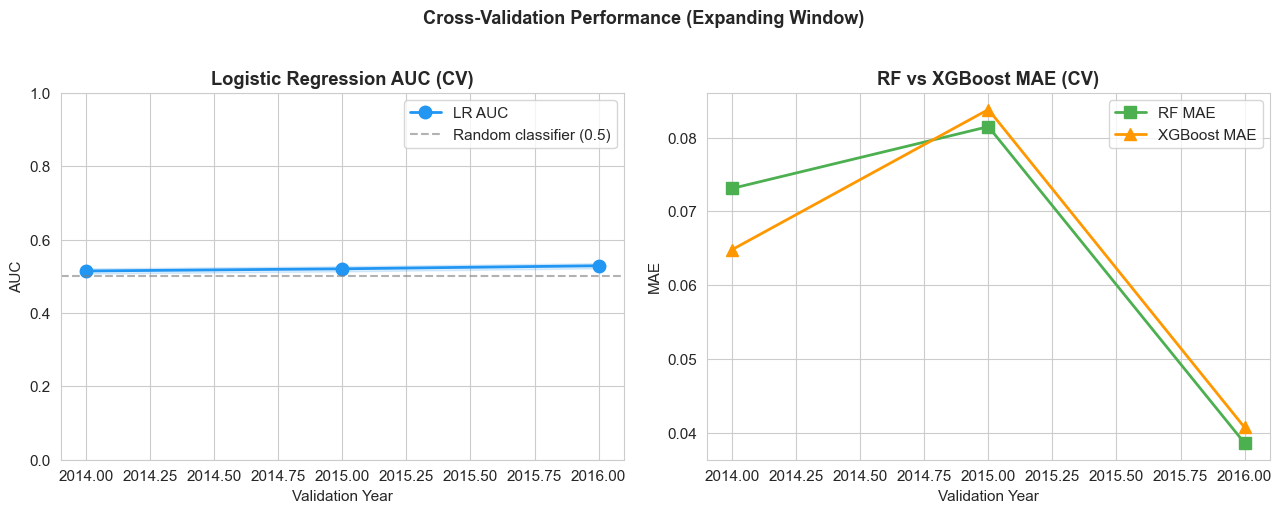

Saved: cv_results.png


In [20]:
# CV metrics visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# AUC across folds
ax = axes[0]
ax.plot(lr_cv_df['val_year'], lr_cv_df['auc'], 'o-', color='#2196F3',
        label='LR AUC', linewidth=2, markersize=9)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Random classifier (0.5)')
ax.fill_between(lr_cv_df['val_year'],
                lr_cv_df['auc'] - lr_cv_df['auc'].std(),
                lr_cv_df['auc'] + lr_cv_df['auc'].std(),
                alpha=0.15, color='#2196F3')
ax.set_title('Logistic Regression AUC (CV)', fontweight='bold')
ax.set_xlabel('Validation Year')
ax.set_ylabel('AUC')
ax.set_ylim(0, 1)
ax.legend()

# MAE comparison
ax = axes[1]
ax.plot(rf_cv_df['val_year'], rf_cv_df['mae'], 's-', color='#4CAF50',
        label='RF MAE', linewidth=2, markersize=9)
if XGB_AVAILABLE and xgb_cv_df is not None:
    ax.plot(xgb_cv_df['val_year'], xgb_cv_df['mae'], '^-', color='#FF9800',
            label='XGBoost MAE', linewidth=2, markersize=9)
ax.set_title('RF vs XGBoost MAE (CV)', fontweight='bold')
ax.set_xlabel('Validation Year')
ax.set_ylabel('MAE')
ax.legend()

plt.suptitle('Cross-Validation Performance (Expanding Window)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cv_results.png', bbox_inches='tight')
plt.show()
print('Saved: cv_results.png')

## Step 7: Final Out-of-Sample Evaluation (2017)

All three models are retrained on the full 2013–2016 dataset and evaluated on  
the held-out **2017** observations (true out-of-sample test).


In [21]:
print('=' * 65)
print('FINAL OUT-OF-SAMPLE EVALUATION  —  Test Year: 2017')
print('=' * 65)

X_fin, y_fin_r, y_fin_c, X_te, y_te_r, y_te_c, te_df = get_split(
    features_df, FINAL_TRAIN_YEARS, TEST_YEAR)
print(f'Final training: {FINAL_TRAIN_YEARS}  ({len(X_fin)} obs)')
print(f'Test set:       {TEST_YEAR}           ({len(X_te)} obs)\n')

# --- Logistic Regression ---
scaler_lr = StandardScaler()
X_fin_sc  = scaler_lr.fit_transform(X_fin)
X_te_sc   = scaler_lr.transform(X_te)

lr_final = LogisticRegression(C=BEST_C_LR, max_iter=2000, random_state=42, solver='lbfgs')
lr_final.fit(X_fin_sc, y_fin_c)
lr_prob = lr_final.predict_proba(X_te_sc)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)

print(f'Logistic Regression (Test {TEST_YEAR}):')
print(f'  Accuracy : {accuracy_score(y_te_c, lr_pred):.4f}')
print(f'  AUC      : {roc_auc_score(y_te_c, lr_prob):.4f}')

# --- Random Forest ---
max_d, min_leaf = BEST_PARAMS_RF
rf_final = RandomForestRegressor(n_estimators=100, max_depth=max_d,
                                  min_samples_leaf=min_leaf, random_state=42, n_jobs=-1)
rf_final.fit(X_fin, y_fin_r)
rf_pred = rf_final.predict(X_te)

print(f'\nRandom Forest (Test {TEST_YEAR}):')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_te_r, rf_pred)):.6f}')
print(f'  MAE  : {mean_absolute_error(y_te_r, rf_pred):.6f}')

# --- XGBoost ---
if XGB_AVAILABLE:
    max_d_x, lr_x = BEST_PARAMS_XGB
    xgb_final = xgb.XGBRegressor(
        n_estimators=100, max_depth=max_d_x, learning_rate=lr_x,
        subsample=0.8, random_state=42, verbosity=0)
    xgb_final.fit(X_fin, y_fin_r)
    xgb_pred = xgb_final.predict(X_te)
    print(f'\nXGBoost (Test {TEST_YEAR}):')
    print(f'  RMSE : {np.sqrt(mean_squared_error(y_te_r, xgb_pred)):.6f}')
    print(f'  MAE  : {mean_absolute_error(y_te_r, xgb_pred):.6f}')

# Store test predictions
lr_val_preds[TEST_YEAR]  = {'tickers': te_df['ticker'].values,
                             'score': lr_prob,  'actual': y_te_r}
rf_val_preds[TEST_YEAR]  = {'tickers': te_df['ticker'].values,
                             'score': rf_pred,  'actual': y_te_r}
if XGB_AVAILABLE:
    xgb_val_preds[TEST_YEAR] = {'tickers': te_df['ticker'].values,
                                 'score': xgb_pred, 'actual': y_te_r}

FINAL OUT-OF-SAMPLE EVALUATION  —  Test Year: 2017
Final training: [2013, 2014, 2015, 2016]  (1948 obs)
Test set:       2017           (501 obs)

Logistic Regression (Test 2017):
  Accuracy : 0.5110
  AUC      : 0.5130

Random Forest (Test 2017):
  RMSE : 0.072054
  MAE  : 0.054635

XGBoost (Test 2017):
  RMSE : 0.071580
  MAE  : 0.054611


## Step 8: Portfolio Construction & Evaluation

For each year and model, we:
1. Rank stocks by predicted score (probability for LR, predicted return for RF/XGB)
2. Select the **top 20%** as the long portfolio
3. Compute equal-weighted portfolio return = mean actual Sep return of selected stocks
4. Compare to **benchmark** = equal-weighted return of all stocks in that year

We report results for **all four evaluation years** (3 CV + 1 final test).


In [22]:
PORTFOLIO_TOPK = 0.20  # top 20%


def compute_portfolio_return(preds_dict, year, topk=PORTFOLIO_TOPK):
    """
    Rank stocks by predicted score, select top topk fraction,
    return (portfolio_ret, benchmark_ret, excess_ret, n_portfolio).
    """
    preds   = preds_dict[year]
    scores  = preds['score']
    actuals = preds['actual']
    n       = len(scores)
    n_port  = max(1, int(n * topk))

    # Top-k indices by score (descending)
    top_idx = np.argsort(scores)[::-1][:n_port]

    portfolio_ret = float(np.mean(actuals[top_idx]))
    benchmark_ret = float(np.mean(actuals))
    excess_ret    = portfolio_ret - benchmark_ret
    return portfolio_ret, benchmark_ret, excess_ret, n_port


# Models to evaluate
models_portfolio = [
    ('Logistic Regression', lr_val_preds),
    ('Random Forest',       rf_val_preds),
]
if XGB_AVAILABLE:
    models_portfolio.append(('XGBoost', xgb_val_preds))

ALL_EVAL_YEARS = [2014, 2015, 2016, 2017]
portfolio_results = {}

print('=' * 72)
print(f'PORTFOLIO EVALUATION  —  Top {int(PORTFOLIO_TOPK*100)}% Long Portfolio')
print('=' * 72)

for model_name, preds_dict in models_portfolio:
    print(f'\n{model_name}:')
    print(f'  {"Year":<8} {"Portfolio":>14} {"Benchmark":>12} {"Excess":>12} {"N stocks":>10}')
    print('  ' + '-' * 58)
    results = []
    for year in ALL_EVAL_YEARS:
        if year not in preds_dict:
            continue
        p, b, e, n = compute_portfolio_return(preds_dict, year)
        results.append({'year': year, 'portfolio': p, 'benchmark': b, 'excess': e, 'n': n})
        print(f'  {year:<8} {p:>14.4%} {b:>12.4%} {e:>12.4%} {n:>10}')
    rdf = pd.DataFrame(results)
    portfolio_results[model_name] = rdf
    print(f'  {"Mean":<8} {rdf.portfolio.mean():>14.4%} {rdf.benchmark.mean():>12.4%} '
          f'{rdf.excess.mean():>12.4%}')

PORTFOLIO EVALUATION  —  Top 20% Long Portfolio

Logistic Regression:
  Year          Portfolio    Benchmark       Excess   N stocks
  ----------------------------------------------------------
  2014           -2.3001%     -2.5435%      0.2434%         97
  2015           -2.2621%     -2.9591%      0.6971%         97
  2016            0.9903%     -0.1090%      1.0993%         99
  2017            2.5033%      2.7005%     -0.1972%        100
  Mean           -0.2672%     -0.7278%      0.4606%

Random Forest:
  Year          Portfolio    Benchmark       Excess   N stocks
  ----------------------------------------------------------
  2014           -3.5195%     -2.5435%     -0.9759%         97
  2015           -5.3604%     -2.9591%     -2.4013%         97
  2016            0.3717%     -0.1090%      0.4807%         99
  2017            3.4176%      2.7005%      0.7171%        100
  Mean           -1.2727%     -0.7278%     -0.5449%

XGBoost:
  Year          Portfolio    Benchmark       Exc

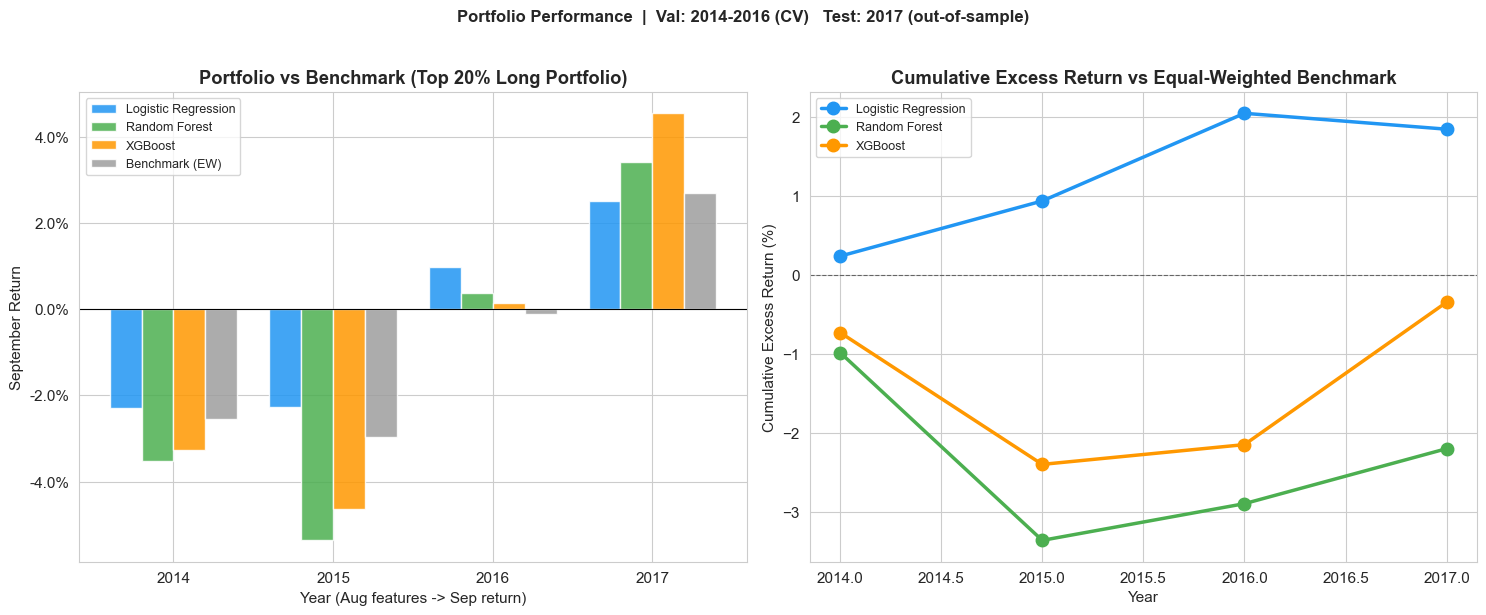

Saved: portfolio_performance.png


In [23]:
# Portfolio performance visualization
n_models = len(models_portfolio)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Bar chart: portfolio vs benchmark by year ---
ax = axes[0]
x = np.arange(len(ALL_EVAL_YEARS))
width = 0.8 / (n_models + 1)
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9E9E9E']

for i, (model_name, preds_dict) in enumerate(models_portfolio):
    rdf = portfolio_results[model_name]
    port_rets = [rdf.loc[rdf['year'] == y, 'portfolio'].values[0]
                 if y in rdf['year'].values else np.nan for y in ALL_EVAL_YEARS]
    ax.bar(x + i * width, port_rets, width, label=model_name,
           color=bar_colors[i], alpha=0.85)

# Benchmark (use LR's benchmark, same for all models)
rdf0 = portfolio_results['Logistic Regression']
bench_rets = [rdf0.loc[rdf0['year'] == y, 'benchmark'].values[0]
              if y in rdf0['year'].values else np.nan for y in ALL_EVAL_YEARS]
ax.bar(x + n_models * width, bench_rets, width, label='Benchmark (EW)',
       color=bar_colors[-1], alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + (n_models / 2) * width)
ax.set_xticklabels(ALL_EVAL_YEARS)
ax.set_xlabel('Year (Aug features -> Sep return)')
ax.set_ylabel('September Return')
ax.set_title('Portfolio vs Benchmark (Top 20% Long Portfolio)', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1%}'))
ax.legend(fontsize=9)

# --- Cumulative excess return ---
ax = axes[1]
for (model_name, _), color in zip(models_portfolio, bar_colors):
    rdf = portfolio_results[model_name]
    cum_exc = (1 + rdf['excess']).cumprod() - 1
    ax.plot(rdf['year'], cum_exc * 100, 'o-', label=model_name,
            color=color, linewidth=2.5, markersize=9)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative Excess Return (%)')
ax.set_title('Cumulative Excess Return vs Equal-Weighted Benchmark', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Portfolio Performance  |  Val: 2014-2016 (CV)   Test: 2017 (out-of-sample)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('portfolio_performance.png', bbox_inches='tight')
plt.show()
print('Saved: portfolio_performance.png')

## Step 9: Robustness Analysis

We examine two robustness dimensions:
1. **Feature importance** — which signals drive each model's predictions?
2. **Cutoff sensitivity** — does performance hold for different portfolio sizes?


9.1  Feature Importance


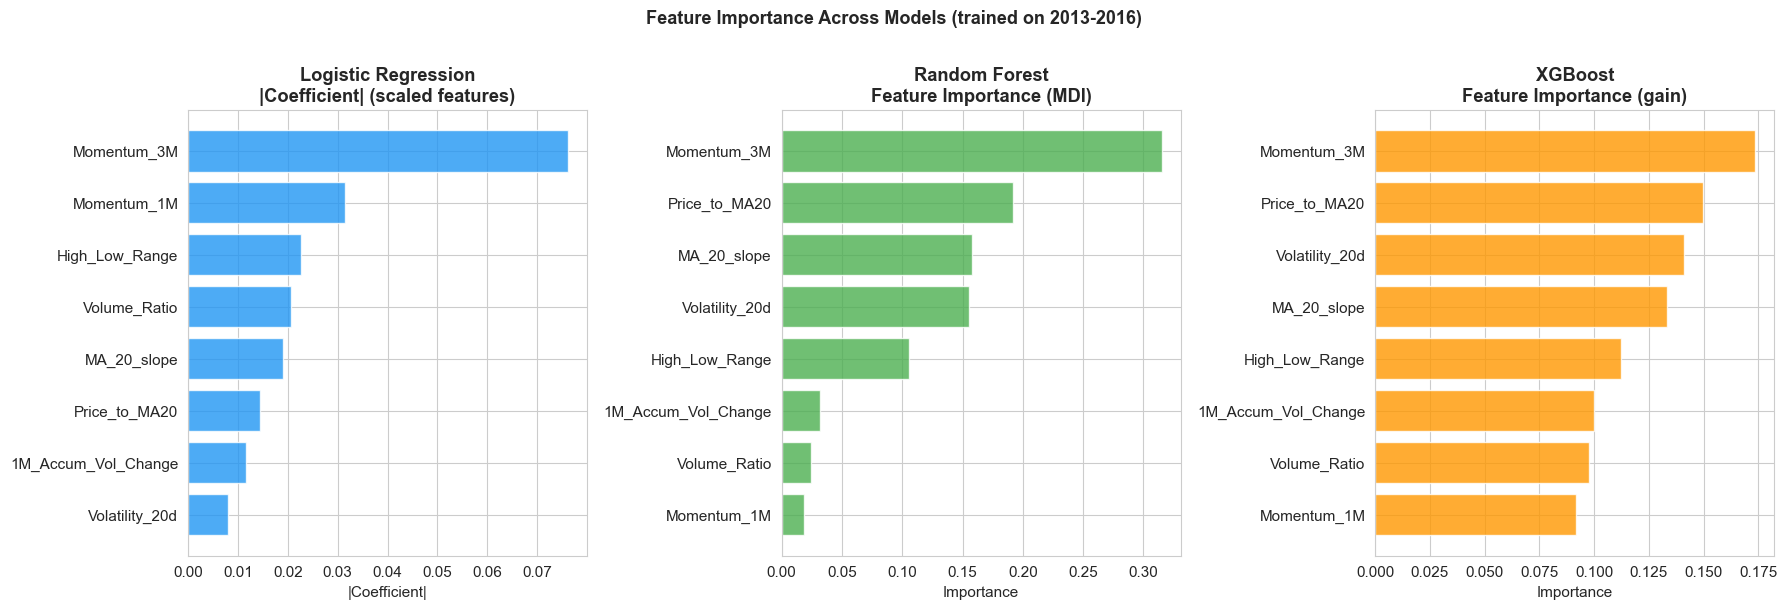

Saved: feature_importance.png


In [24]:
print('9.1  Feature Importance')
print('=' * 55)

n_imp_plots = 2 + int(XGB_AVAILABLE)
fig, axes = plt.subplots(1, n_imp_plots, figsize=(6 * n_imp_plots, 6))
if n_imp_plots == 1:
    axes = [axes]

# LR absolute coefficients
ax = axes[0]
coef = np.abs(lr_final.coef_[0])
order = np.argsort(coef)  # ascending for barh
ax.barh([FEATURE_COLS[i] for i in order], coef[order], color='#2196F3', alpha=0.8)
ax.set_title('Logistic Regression\n|Coefficient| (scaled features)', fontweight='bold')
ax.set_xlabel('|Coefficient|')

# RF feature importance
ax = axes[1]
imp_rf = rf_final.feature_importances_
order_rf = np.argsort(imp_rf)
ax.barh([FEATURE_COLS[i] for i in order_rf], imp_rf[order_rf], color='#4CAF50', alpha=0.8)
ax.set_title('Random Forest\nFeature Importance (MDI)', fontweight='bold')
ax.set_xlabel('Importance')

# XGB feature importance
if XGB_AVAILABLE:
    ax = axes[2]
    imp_xgb = xgb_final.feature_importances_
    order_xgb = np.argsort(imp_xgb)
    ax.barh([FEATURE_COLS[i] for i in order_xgb], imp_xgb[order_xgb], color='#FF9800', alpha=0.8)
    ax.set_title('XGBoost\nFeature Importance (gain)', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Across Models (trained on 2013-2016)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

9.2  Portfolio Cutoff Sensitivity (Test Year 2017)


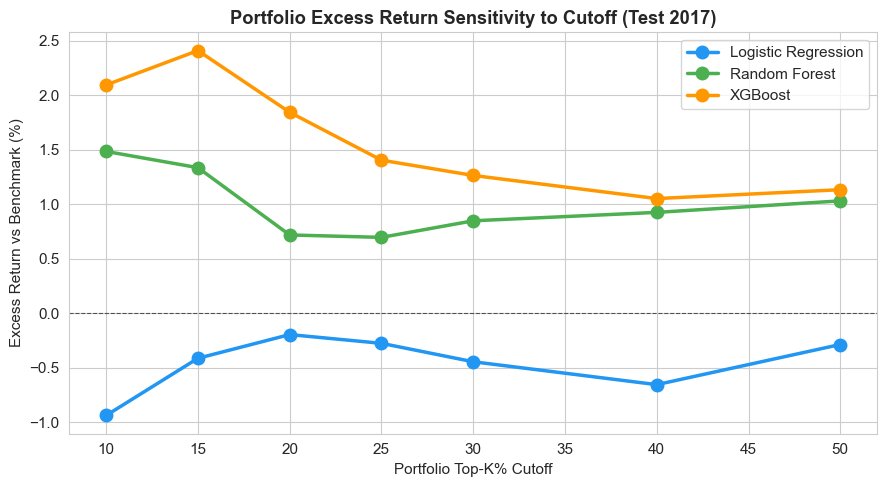

Saved: sensitivity.png

Excess Return vs Benchmark by Cutoff (Test 2017):
  Cutoff  Logistic Regre   Random Forest         XGBoost
--------------------------------------------------------
     10%        -0.9395%         1.4837%         2.0935%
     15%        -0.4149%         1.3347%         2.4090%
     20%        -0.1972%         0.7171%         1.8429%
     25%        -0.2774%         0.6949%         1.4035%
     30%        -0.4465%         0.8470%         1.2632%
     40%        -0.6566%         0.9242%         1.0510%
     50%        -0.2882%         1.0298%         1.1323%


In [25]:
print('9.2  Portfolio Cutoff Sensitivity (Test Year 2017)')
print('=' * 55)

cutoffs = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
sensitivity = {m[0]: [] for m in models_portfolio}

for topk in cutoffs:
    for model_name, preds_dict in models_portfolio:
        if TEST_YEAR in preds_dict:
            _, _, exc, _ = compute_portfolio_return(preds_dict, TEST_YEAR, topk)
            sensitivity[model_name].append(exc)
        else:
            sensitivity[model_name].append(np.nan)

fig, ax = plt.subplots(figsize=(9, 5))
s_colors = ['#2196F3', '#4CAF50', '#FF9800']
for (model_name, _), color in zip(models_portfolio, s_colors):
    ax.plot([c * 100 for c in cutoffs], [v * 100 for v in sensitivity[model_name]],
            'o-', label=model_name, color=color, linewidth=2.5, markersize=9)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel('Portfolio Top-K% Cutoff')
ax.set_ylabel('Excess Return vs Benchmark (%)')
ax.set_title(f'Portfolio Excess Return Sensitivity to Cutoff (Test {TEST_YEAR})',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('sensitivity.png', bbox_inches='tight')
plt.show()
print('Saved: sensitivity.png')

# Summary table
print(f'\nExcess Return vs Benchmark by Cutoff (Test {TEST_YEAR}):')
hdr = f'{"Cutoff":>8}' + ''.join(f'  {m[0][:14]:>14}' for m in models_portfolio)
print(hdr)
print('-' * (8 + 16 * len(models_portfolio)))
for i, topk in enumerate(cutoffs):
    row = f'{topk:>8.0%}'
    for model_name, _ in models_portfolio:
        val = sensitivity[model_name][i]
        row += f'  {val:>14.4%}' if not np.isnan(val) else f'  {"N/A":>14}'
    print(row)

## Conclusion

This notebook implemented a complete machine learning pipeline for cross-sectional  
stock selection using S&P 500 data (2013–2018).

### Key Findings

**Feature Engineering:** We constructed 8 technical indicators (momentum, trend,  
volatility, and volume) at August month-end, targeting September cross-sectional returns.

**Model Performance (CV, 2014–2016):**
- **Logistic Regression** — simple interpretable baseline; evaluated by Accuracy and AUC
- **Random Forest** — captures nonlinear relationships; evaluated by RMSE and MAE
- **XGBoost** — gradient boosting on structured data; evaluated by RMSE and MAE

**Portfolio Evaluation (out-of-sample 2017):** The top-20% long portfolio was compared  
against the equal-weighted S&P 500 benchmark across all three models.

**Robustness:** Feature importance analysis revealed the dominant predictive signals,  
and sensitivity analysis showed the stability of portfolio excess returns across  
different portfolio cutoff thresholds.

### Limitations & Future Work

- The August-only design limits the number of temporal training points (5 years).
- Transaction costs, slippage, and short-selling constraints are not modeled.
- Future work could incorporate fundamental data (P/E, earnings surprise) and  
  alternative signals (sentiment, analyst revisions).
